# Code to determine the Correlations metric


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
# utilized in upset_frequency
def load_all_league_data():
    """
    Load match data and standings for all available leagues.
    
    Returns:
        tuple: (league_data_dict, standings_dict) where each is a dict of league_name -> DataFrame
    """
    base_dir = Path().resolve()
    
    # Define league configurations
    leagues = {
        'Premier League': {
            'matches_file': 'premier_league1_std.csv',
            'standings_file': 'premier_league_standings_all_seasons.csv'
        },
        'Serie A': {
            'matches_file': 'serie_a_std.csv',
            'standings_file': 'serie_a_standings_all_seasons.csv'
        },
        'Bundesliga': {
            'matches_file': 'bundesliga_std.csv',
            'standings_file': 'bundesliga_standings_all_seasons.csv'
        },
        'La Liga': {
            'matches_file': 'la_liga_std.csv',
            'standings_file': 'la_liga_standings_all_seasons.csv'
        }
    }
    
    league_data = {}
    standings_data = {}
    
    print("Loading league data...")   
    for league_name, config in leagues.items():
        # Load match data
        matches_path = base_dir / "../csv/processed" / config['matches_file']
        if matches_path.exists():
            matches_df = pd.read_csv(matches_path)
            matches_df['date'] = pd.to_datetime(matches_df['date'])
            league_data[league_name] = matches_df
            print(f"✓ Loaded {league_name} matches: {len(matches_df):,} matches")
        else:
            print(f"✗ Warning: {matches_path} not found")
            
        # Load standings data
        standings_path = base_dir / "../csv/auxiliary" / config['standings_file']
        if standings_path.exists():
            standings_df = pd.read_csv(standings_path)
            standings_data[league_name] = standings_df
            print(f"✓ Loaded {league_name} standings: {len(standings_df):,} team-seasons")
        else:
            print(f"✗ Warning: {standings_path} not found")
    
    print(f"\nSuccessfully loaded {len(league_data)} leagues")
    return league_data, standings_data
league_data, standings_data = load_all_league_data()
len(league_data["Premier League"]["season"].unique())

Loading league data...
✓ Loaded Premier League matches: 8,360 matches
✓ Loaded Premier League standings: 440 team-seasons
✓ Loaded Serie A matches: 8,518 matches
✓ Loaded Serie A standings: 454 team-seasons
✓ Loaded Bundesliga matches: 6,426 matches
✓ Loaded Bundesliga standings: 378 team-seasons
✓ Loaded La Liga matches: 8,740 matches
✓ Loaded La Liga standings: 460 team-seasons

Successfully loaded 4 leagues


22

In [2]:

results = []
def goal_calculation(team, games):
    home_points = games.loc[games["home_team"] == team, "home_team_points"].sum() #sum up every home games points
    away_points = games.loc[games["away_team"] == team, "away_team_points"].sum() #sum up every away games points
    return home_points + away_points


def correlation(team,season, matches_played):
    df = matches_played[matches_played["season"] == season]
    df = df[(df["home_team"] == team) | (df["away_team"] == team)]
    df = df.sort_values(by = "date", ascending= True)
    midpoint = len(df) // 2
    first_half = df.iloc[:midpoint]
    second_half = df.iloc[midpoint:]
    first_half_points = goal_calculation(team, first_half)
    second_half_points = goal_calculation(team, second_half)
    first_half_points = (first_half_points/len(first_half))/ 3 * 100
    second_half_points = (second_half_points/len(second_half)) / 3 * 100
    dictionary= {"team": team, "season": season, "first_half_points": first_half_points, "second_half_points": second_half_points}

    return dictionary

skilled_leagues = pd.read_csv("/Users/joeyli/skillvsluck/data/european_soccer/csv/analysis/simulations/skill_based_simulations/skill_based_league.csv")

for league in league_data:
    # df = league_data[league] normal leagues
    df = skilled_leagues[skilled_leagues["league"] ==league].copy()
    unique_pairs = set(zip(df["season"], df["home_team"]))
    for season, team in unique_pairs:
        second=correlation(team, season, df)
        second["league"] = league
        results.append(second)
allleagues = pd.DataFrame(results)
allleagues=allleagues.sort_values(by = ["league", "season", "team"], ascending= True)

In [3]:
allleagues=allleagues.sort_values(by = ["league", "season", "team"], ascending= True)
allleagues.to_csv("skill_league_correlation_metrics.csv", index=False)
allleagues


,team,season,first_half_points,second_half_points,league
910,BAY,2004,100.000000,100.000000,Bundesliga
1068,BIE,2004,29.411765,29.411765,Bundesliga
1029,BOC,2004,11.764706,11.764706,Bundesliga
936,DOR,2004,64.705882,64.705882,Bundesliga
894,FRE,2004,0.000000,0.000000,Bundesliga
...,...,...,...,...,...
878,ROM,2024,78.947368,78.947368,Serie A
575,TOR,2024,47.368421,47.368421,Serie A
874,UDI,2024,42.105263,42.105263,Serie A
574,VEN,2024,5.263158,5.263158,Serie A


In [4]:
allleagues

,team,season,first_half_points,second_half_points,league
910,BAY,2004,100.000000,100.000000,Bundesliga
1068,BIE,2004,29.411765,29.411765,Bundesliga
1029,BOC,2004,11.764706,11.764706,Bundesliga
936,DOR,2004,64.705882,64.705882,Bundesliga
894,FRE,2004,0.000000,0.000000,Bundesliga
...,...,...,...,...,...
878,ROM,2024,78.947368,78.947368,Serie A
575,TOR,2024,47.368421,47.368421,Serie A
874,UDI,2024,42.105263,42.105263,Serie A
574,VEN,2024,5.263158,5.263158,Serie A


# Create Plots

     team  season  first_half_points  second_half_points      league
910   BAY    2004         100.000000          100.000000  Bundesliga
1068  BIE    2004          29.411765           29.411765  Bundesliga
1029  BOC    2004          11.764706           11.764706  Bundesliga
936   DOR    2004          64.705882           64.705882  Bundesliga
894   FRE    2004           0.000000            0.000000  Bundesliga
...   ...     ...                ...                 ...         ...
878   ROM    2024          78.947368           78.947368     Serie A
575   TOR    2024          47.368421           47.368421     Serie A
874   UDI    2024          42.105263           42.105263     Serie A
574   VEN    2024           5.263158            5.263158     Serie A
876   VER    2024          31.578947           31.578947     Serie A

[1732 rows x 5 columns]


/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_57480/1394812013.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_57480/1394812013.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_57480/1394812013.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/8x/dwdknq6506sfclr78z86zfc40000gn/T/ipykernel_57480/1394812013.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


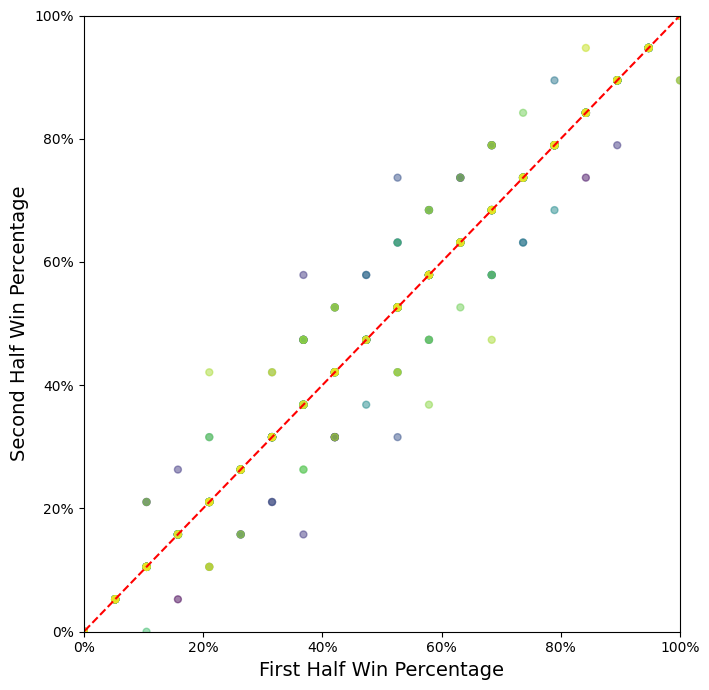

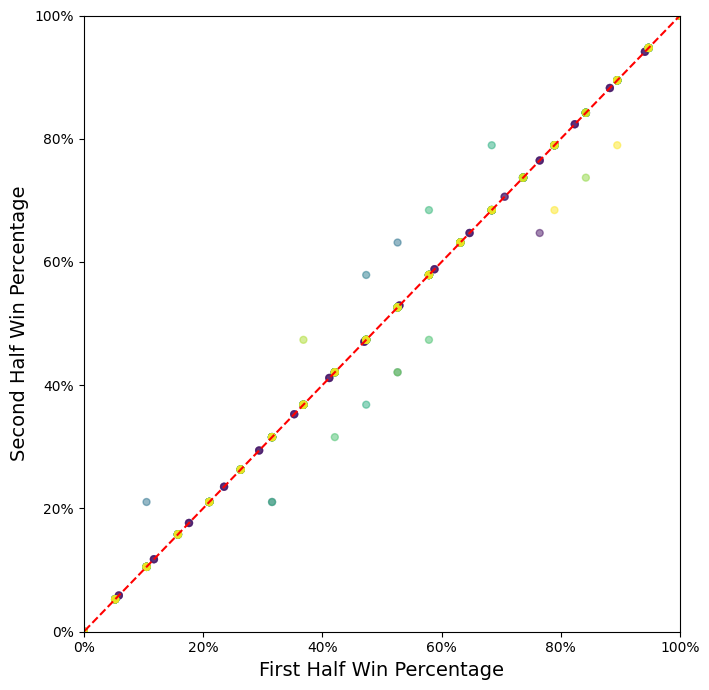

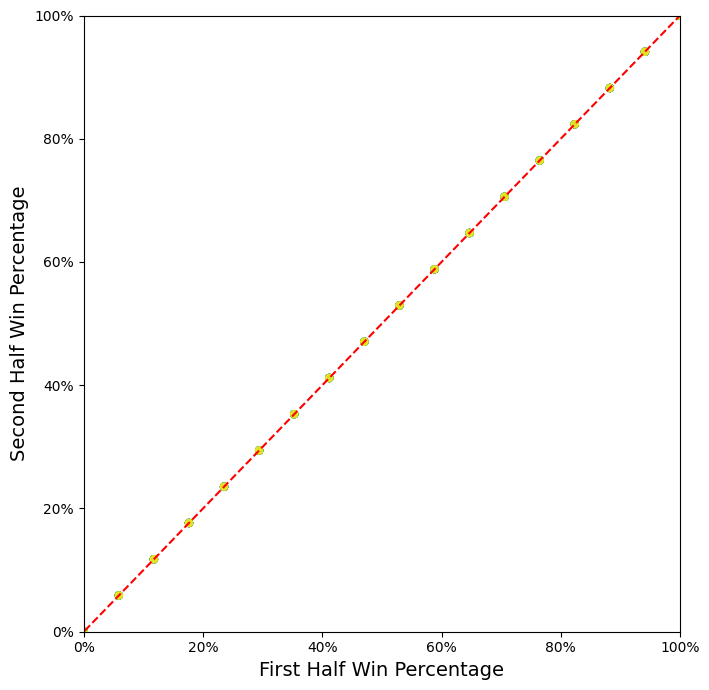

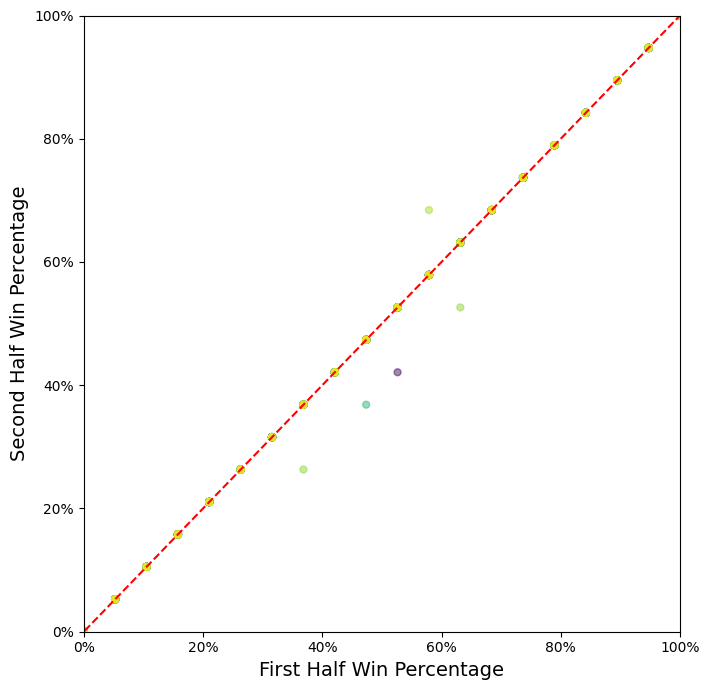

In [5]:
print(allleagues)
import matplotlib.ticker as mtick

for league in league_data:
    fig, ax = plt.subplots(figsize=(7,7), constrained_layout=True)
    df = allleagues[allleagues["league"] == league].copy()
    df["season"] = df["season"].astype(int)

     #/ by points per game and divide by 3 to get win percentage
    

    df.plot(
        x="first_half_points", y="second_half_points", kind="scatter", ax=ax, marker='o', alpha=0.5, s=25,          # circle marker
        c=df["season"],  # 'c' instead of 'color' for a color map
        cmap="viridis"
    )
    # Remove the automatic colorbar
    for cbar in ax.figure.axes:
        if cbar is not ax:  # any other axes besides main one
            cbar.remove()
    # ax.set_aspect('equal', adjustable='box')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

    min_val = min(plt.xlim()[0], plt.ylim()[0])
    max_val = max(plt.xlim()[1], plt.ylim()[1])
    line_vals = np.linspace(min_val, max_val, 100) # Generate points for the line
    plt.xlim(0, 100)
    plt.ylim(0, 100)

# Plot the y=x line
    plt.plot(line_vals, line_vals, color='red', linestyle='--', label='y=x')
    plt.title("")
    plt.xlabel("First Half Win Percentage", fontsize = 14)
    plt.ylabel("Second Half Win Percentage", fontsize = 14)
    plt.tight_layout()
    plt.savefig(f"{league}_correlation.png".lower())


